# Optimization

#### Imports

In [241]:
%reload_ext autoreload
%autoreload 2

In [242]:
import sys
import os

# Add the parent directory (or another appropriate path) to sys.path so Python can find Exclusion_functions
notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, '..'))
function_dir = os.path.abspath(os.path.join(parent_dir, 'Function_Files'))
if function_dir not in sys.path:
    sys.path.append(function_dir)

import pandas as pd
import datetime
import numpy as np

import Exclusion_functions as ef
import Optimization_functions as of
import Final_report_functions as frf

In [243]:
CATEGORY = "Cutlery"
TODAY = datetime.datetime.now().strftime('%m.%d.%Y')
IP_PATH = f"{parent_dir}\\Data\\"
IP_PATH_CAT = f"{parent_dir}\\Data\\{CATEGORY}\\"
OP_PATH = f"{parent_dir}\\Data\\{CATEGORY}\\Output\\"

In [244]:
# read back in group transactions from Taxonomy step
cat_data_final = pd.read_csv(f"{OP_PATH}{CATEGORY}_matches.csv")
transactions = pd.read_csv(f"{OP_PATH}Cutlery Data - Cleaned.csv")

C:\Users\zwayne\AppData\Local\Temp\ipykernel_28736\3391324984.py:3: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  transactions = pd.read_csv(f"{OP_PATH}Cutlery Data - Cleaned.csv")


#### Get Exclusions

In [245]:
# Merge matches onto transactions
transactions_merged = transactions.merge(
    cat_data_final[["Entity--Item", "Matches"]],
    on="Entity--Item",
    how="left"
)

# Define the aggregation dictionary.
agg_dict = {
    "Qty": "sum",
    "Net Cost": "sum",
    "Gross Cost": "sum",
    "Matches": "first",
    "VGN": "first",
    "Customer Class": "first",
    "Price Group Name": "first",
    "Case Pack": "mean",
}


transactions_merged["Case Pack"] = pd.to_numeric(transactions_merged["Case Pack"], errors="coerce")

# Group by item/customer and aggregat
transactions_grouped_by_item_customer = (
    transactions_merged
    .groupby(["Entity--Item", "Customer Code"], dropna=False)
    .agg(agg_dict)
    .rename(columns={
        "Qty": "Total_Qty",
        "Net Cost": "Total_Net_Cogs",
        "Gross Cost": "Total_Gross_Cost",
        "Price Group Name": "Customer_Name",
    })
    .reset_index()
)

If you have any vendors that you don't want to get rid of, but are not preferred

In [246]:
# I have a vendor exclusion sheet from ID team that I am reading in and labeling any item from one of these vendors for exclusion
# I also add in VB Vendors because excluded Vendors = Do Not Swap Away - which we want for PL Vendors
vendor_exclusions = pd.read_excel(f"{IP_PATH}Customer and Vendor Exclusions.xlsx", sheet_name="VGN Table list", skiprows=2)
vendor_exclusions = set(vendor_exclusions[vendor_exclusions['Nonaddressable'] == 'X']['VGN'].tolist())
# vendor_exclusions = vendor_exclusions.union(['Direct Link','Carryout Bags, Inc.'])
vendor_exclusions = cat_data_final[cat_data_final['VGN'].isin(vendor_exclusions)]['Entity--Item'].unique().tolist()
print(f"Found {len(vendor_exclusions)} unqiue SKUS bought by excluded vendors")

Found 168 unqiue SKUS bought by excluded vendors


If you have any customers that you want to make sure none of their skus change

In [247]:
# I have a Customer exclusion sheet from ID team that I am reading in and labeling any item that goes to one of these Customer for exclusion
customer_exclusions = pd.read_excel(f"{IP_PATH}Customer and Vendor Exclusions.xlsx", sheet_name="Customer Table list", skiprows=2)
customer_exclusions = set(customer_exclusions[customer_exclusions['Nonaddressable'] == 'X']['Customer Name'].tolist())
get_skus_to_excl_cust = ef.get_skus_to_excl_cust(transactions_grouped_by_item_customer, customer_exclusions)
customer_exclusions_skus = get_skus_to_excl_cust['Entity--Item'].unique().tolist()

Found 1432 unique SKUs bought by excluded customers


If don't want to change what goes to redistributors

In [248]:
# Any item that goes to a redistributor is excluded
redi = ef.get_skus_to_redi(transactions_grouped_by_item_customer)
redi_skus = redi['Entity--Item'].unique().tolist()

Found 1042 unique SKUs serving redi customers


* Preferred: Swap to these Vendor's SKUs whenever possible
* Maintain: Not Preferred, but make sure not to get rid of
* Kill: Look to cut
* Not in any list: If there's a good swap make it

In [249]:
# You can customize this based on your business requirements
preferred = cat_data_final[cat_data_final['VGN'].isin(['Direct Link','Carryout Bags, Inc.'])]['Entity--Item'].unique().tolist()
maintain = list(set(vendor_exclusions + redi_skus + customer_exclusions_skus))
kill = cat_data_final[cat_data_final['VGN'].isin(['Bargreen Ellingson','Petro Plastics Corp'])]['Entity--Item'].unique().tolist()

print(f"Preferred SKUs: {len(preferred)}")
print(f"Maintain SKUs (cannot take swaps): {len(maintain)}")
print(f"Try to kill SKUs (must swap away): {len(kill)}")

Preferred SKUs: 387
Maintain SKUs (cannot take swaps): 1952
Try to kill SKUs (must swap away): 11


In [261]:
# Process SKU groups (maintain, kill, preferred) with precedence order and validation
# This returns the modified DataFrame with filtered matches for preferred SKUs
cat_data_processed, maintain_final, kill_final, preferred_final, could_not_kill = of.process_sku_groups(cat_data_final, maintain, kill, preferred)


--- Processing SKU Groups ---
Processing 387 preferred SKUs...
745 Non-Preferred SKUs have a Preferred SKU Swap and are thus added to the Kill list to be swapped away.
Applying precedence order: preferred > maintain > kill to SKUs on multiple lists
Found 575 SKUs in multiple groups
575 SKUs adjusted after being on multiple lists
Final group sizes after precedence:
  Preferred: 387
  Kill: 456
  Maintain: 1677
Checking kill SKUs for valid matches...
All kill SKUs have valid matches
--- SKU Group Processing Complete ---


In [251]:
# read in rebates file from ID - create cost_diff matrix
# this matrix is made using my understanding of the cost analyis process - complete with adjusting for case pack and taking into account POD/Non-POD
# the resulting matrix cell i, j is the cost saved by swapping from item i to item j
rebates = pd.read_excel(f"{IP_PATH}\\Rebates.xlsx")
cost_diff_df = of.get_cost_diff_df(cat_data_processed, transactions, rebates)

#### Loop through optimization

In [ ]:
# here i loop through an optimization
# the optimization logic is highlighed in the slides
# but essentially I am lowering the amount of vendors i am allowing till the problem becomes infeasible (i.e. I can't swap all items to 1 vendor for example)
# and then I graph the savings by the vendors - the goal being to try to find a good medium between getting savings and removing vendors
# if you only care about savings then you need not have the max_supplier constraint
results = of.solve_swap_optimization_looped(cat_data_processed, cost_diff_df, maintain_ids=maintain_final, kill_ids=kill_final, preferred_ids=preferred_final)

--- Initializing Looped Optimization Problem ---
Starting optimization loop. Initial max suppliers: 224

--- Solving for Max Suppliers <= 224 ---
--- Initializing Swap Optimization Problem ---
--- Optimization Results ---
Status: Optimal
Total yearly cost savings: $3,258,034.32
Number of swaps: 1776
Active suppliers: 191

--- Solving for Max Suppliers <= 212 ---
--- Initializing Swap Optimization Problem ---
--- Optimization Results ---
Status: Optimal
Total yearly cost savings: $3,258,034.32
Number of swaps: 1778
Active suppliers: 191

--- Solving for Max Suppliers <= 201 ---
--- Initializing Swap Optimization Problem ---
--- Optimization Results ---
Status: Optimal
Total yearly cost savings: $3,258,034.32
Number of swaps: 1778
Active suppliers: 191

--- Solving for Max Suppliers <= 190 ---
--- Initializing Swap Optimization Problem ---
--- Optimization Results ---
Status: Optimal
Total yearly cost savings: $3,258,032.97
Number of swaps: 1779
Active suppliers: 190

--- Solving for Max

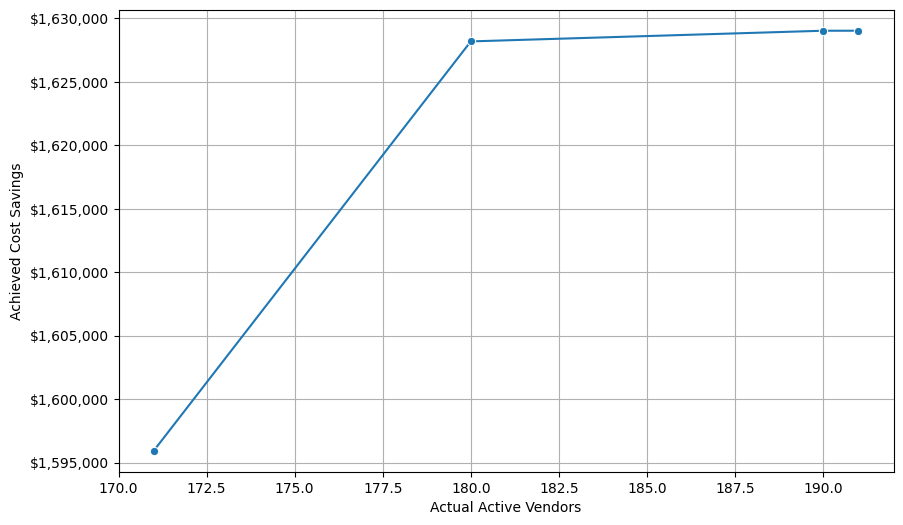

In [253]:
# this graphs the Achieved_Cost_Savings by Actual_Active_Suppliers
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(data=results, x='Actual_Active_Suppliers', y='Achieved_Cost_Savings', marker='o')
plt.xlabel('Actual Active Vendors')
plt.ylabel('Achieved Cost Savings')
plt.gca().yaxis.set_major_formatter('${x:,.0f}')
plt.grid()
plt.show()


#### Run best optimization and update df

In [254]:
max_suppliers_limit = 180
# I set the max_suppliers_limit based on the elbow of the graph above, the data I have is L6M so I scale savings by 2 to get yearly
results = of.solve_swap_optimization(cat_data_processed, cost_diff_df, maintain_ids=maintain_final, kill_ids=kill_final, preferred_ids=preferred_final, max_suppliers = max_suppliers_limit)

--- Initializing Swap Optimization Problem ---
--- Optimization Results ---
Status: Optimal
Total yearly cost savings: $3,256,351.94
Number of swaps: 1787
Active suppliers: 180


In [255]:
updated_df = of.analyze_swap_results(cat_data_final, results)

In [260]:
print("Current Number of SKUs:", len(updated_df['Entity--Item'].unique()))
print("New Number of SKUs:", len(updated_df[updated_df['Final_Volume'] > 0.1]['Entity--Item'].unique()))
print("\n")
print("Volume the Same? ", updated_df['Original_Volume'].sum() == updated_df['Final_Volume'].sum())
print("\n")
print("Current Vendors:", len(updated_df['Original_Supplier'].unique()))
print("New Vendors:", len(updated_df['New_Supplier'].unique()))
print("\n")

print(f"Current Net Cost: ${updated_df['Original_Cost'].sum()*2 :,.2f}")
print(f"New Net Cost:     ${updated_df['Original_Cost'].sum()*2-updated_df['Savings_From_Swapping_Away'].sum()*2 :,.2f}")
print(f"Cost Savings:     ${updated_df['Savings_From_Swapping_Away'].sum()*2:,.2f}")

Current Number of SKUs: 4717
New Number of SKUs: 2929


Volume the Same?  True


Current Vendors: 225
New Vendors: 180


Current Net Cost: $75,233,618.00
New Net Cost:     $71,977,266.06
Cost Savings:     $3,256,351.94


In [37]:
feedback_file = pd.read_csv(f"{OP_PATH}{CATEGORY}_feedback_df.csv")

In [ ]:
# create an enhanced report that I would send a CM with the optimal swaps
frf.create_enhanced_sku_report(updated_df, feedback_file, transactions_grouped_by_item_customer,  f"{OP_PATH}{CATEGORY}_Final_Report_{TODAY}.xlsx" , customer_exclusions = get_skus_to_excl_cust['Customer Code'].unique().tolist(), redi_customers= redi['Customer Code'].unique().tolist())

--- Starting to generate Enhanced SKU Report: c:\Users\zwayne\OneDrive - Advent International\Documents\GitHub\ImperialDadeCategoryManagement\Data\Cutlery\Output\Cutlery_Final_Report_09.08.2025.xlsx ---

--- Processing Sheet: Suggested Swaps ---

--- Processing Sheet: Vendor Performance Summary ---

--- Processing Sheet: Customer Performance Summary ---
--- Successfully created Enhanced SKU Report: c:\Users\zwayne\OneDrive - Advent International\Documents\GitHub\ImperialDadeCategoryManagement\Data\Cutlery\Output\Cutlery_Final_Report_09.08.2025.xlsx ---


True

# Optimization Feedback
if any feedback from the optimization, you can load in here. These two cells/functions will remove the Rejects from the matches, then you can rerun the optimization

In [67]:
suggested_swaps_df = frf.read_and_process_feedback_excel( f"{OP_PATH}Cutlery_Final_Report_09.08.2025.xlsx")

--- Reading feedback from Excel file: c:\Users\zwayne\OneDrive - Advent International\Documents\GitHub\ImperialDadeCategoryManagement\Data\Cutlery\Output\Cutlery_Final_Report_09.08.2025.xlsx ---
Processing sheet: Suggested Swaps...
Successfully extracted data from 'Suggested Swaps'. Found 1186 rows.


In [68]:
cat_data_final = frf.incorporate_swaps_feedback(cat_data_final, suggested_swaps_df)

## Go back and rerun optimization